In [1]:
import logging

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [2]:
spark = (
    SparkSession.builder 
    .appName("MinIO test")
    .master("local[*]")  
    .config("spark.jars.packages", 
        "org.apache.hadoop:hadoop-aws:3.3.4,"
        "com.amazonaws:aws-java-sdk-bundle:1.12.262") 
    .config("spark.hadoop.fs.s3a.endpoint", "http://127.0.0.1:9050") 
    .config("spark.hadoop.fs.s3a.access.key", "adm") 
    .config("spark.hadoop.fs.s3a.secret.key", "secret_pass") 
    .config("spark.hadoop.fs.s3a.path.style.access", "true") 
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") 
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") 
    .getOrCreate()
)

In [3]:
df = spark.read.parquet("s3a://raw-data/taxi-raw/*.parquet")

In [4]:
df.count()

19653012

In [5]:
df_subset = df.filter(F.col("request_datetime") <= "2025-07-03")
print(df_subset.count())

1186658


In [6]:
df_subset.write.mode("overwrite").parquet(f"s3a://silver-data/four-pack")

In [7]:
df_sample = df.sample(withReplacement=False, fraction=0.05, seed=42)

In [9]:
df_sample.explain()

== Physical Plan ==
*(1) Sample 0.0, 0.05, false, 42
+- *(1) ColumnarToRow
   +- FileScan parquet [hvfhs_license_num#0,dispatching_base_num#1,originating_base_num#2,request_datetime#3,on_scene_datetime#4,pickup_datetime#5,dropoff_datetime#6,PULocationID#7,DOLocationID#8,trip_miles#9,trip_time#10L,base_passenger_fare#11,tolls#12,bcf#13,sales_tax#14,congestion_surcharge#15,airport_fee#16,tips#17,driver_pay#18,shared_request_flag#19,shared_match_flag#20,access_a_ride_flag#21,wav_request_flag#22,wav_match_flag#23,cbd_congestion_fee#24] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[s3a://raw-data/taxi-raw/fhvhv_tripdata_2025-07.parquet], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<hvfhs_license_num:string,dispatching_base_num:string,originating_base_num:string,request_d...




### convert data to pandas

In [ ]:
pd_df = df_sample.toPandas()

In [ ]:
pd_df.to_parquet("sample_one.parquet")

### read parquet

In [2]:
pd_df = pd.read_parquet("sample_one.parquet")

### EDA
1. Проверка пропусков
2. Проверка типов данных (Чистовые\категориальные - порядковые, номинальные)
    1) Привести типы к правильному формату (преобразование типов данных, приведение дат)
    2) Проверка уникального числа значений признака в каждой категориальном признаке
    3) Описательные статистики (минимальное, максимальное, среднее, сигма)
3. Распределения признаков
    1) Диаграммы распределений для числовых признаков
    2) Подсчет количества численности каждой категории во всех категориальных признаках
    3) Pairplot (между каждой парой признаков - диаграмма рассеивания и распределения)
4. Проверка выбросов (построить графики boxplot, скрипку)
5. Проверка корреляция между признаками
6. Определение с целевой переменной
7. Проверка на дисбаланс классов
8. Построить таблицы сопряженности для категориальных признаков

In [3]:
pd_df.info() # Интересный момент, что данный датасет в формате .parquet занимает 39 МБ, а при загрузке в pandas 180 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 982448 entries, 0 to 982447
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   hvfhs_license_num     982448 non-null  object        
 1   dispatching_base_num  982448 non-null  object        
 2   originating_base_num  707791 non-null  object        
 3   request_datetime      982448 non-null  datetime64[ns]
 4   on_scene_datetime     982448 non-null  datetime64[ns]
 5   pickup_datetime       982448 non-null  datetime64[ns]
 6   dropoff_datetime      982448 non-null  datetime64[ns]
 7   PULocationID          982448 non-null  int32         
 8   DOLocationID          982448 non-null  int32         
 9   trip_miles            982448 non-null  float64       
 10  trip_time             982448 non-null  int64         
 11  base_passenger_fare   982448 non-null  float64       
 12  tolls                 982448 non-null  float64       
 13 

In [ ]:
# root
#  |-- hvfhs_license_num: string (nullable = true)          --- Компания, которая выдала лицензию
#  |-- dispatching_base_num: string (nullable = true)
#  |-- originating_base_num: string (nullable = true)       --- Номер базы, получивший первоначальный запрос на поездку
#  |-- request_datetime: timestamp_ntz (nullable = true)    --- Дата и время, когда пассажир запросил поезду
#  |-- on_scene_datetime: timestamp_ntz (nullable = true)   --- Дата и время прибытия водителя на место посадки
#  |-- pickup_datetime: timestamp_ntz (nullable = true)     --- Дата и время начала поездки
#  |-- dropoff_datetime: timestamp_ntz (nullable = true)    --- Дата и время высадки
#  |-- PULocationID: integer (nullable = true)              --- ID зоны-посадки
#  |-- DOLocationID: integer (nullable = true)              --- ID зоны-высадки
#  |-- trip_miles: double (nullable = true)                 --- Общее растояние поездки (в милях)
#  |-- trip_time: long (nullable = true)                    --- Общее время поездки (в секундах)
#  |-- base_passenger_fare: double (nullable = true)        --- Базовая стоимость проезда без учета дорожных сборов, чаевых, налогов и др
#  |-- tolls: double (nullable = true)                      --- Общая сумма всех уплаченных за поездку дорожных сборов
#  |-- bcf: double (nullable = true)                        --- Общая сумма, собранная во время поездки для фонда «Автомобиль представительского класса».
#  |-- sales_tax: double (nullable = true)                  --- Общая сумма, собранная во время поездки в качестве налога с продаж штата Нью-Йорк.
#  |-- congestion_surcharge: double (nullable = true)       --- Общая сумма, собранная во время поездки в качестве платы за въезд в зону ограниченного движения в штате Нью-Йорк.
#  |-- airport_fee: double (nullable = true)                --- 2,50 доллара за высадку и посадку в аэропортах ЛаГуардия, Ньюарк и имени Джона Ф. Кеннеди.
#  |-- tips: double (nullable = true)                       --- Общая сумма чаевых, полученных от пассажира.
#  |-- driver_pay: double (nullable = true)                 --- Общая заработная плата водителя (без учета платы за проезд по платным дорогам и чаевых, а также за вычетом комиссионных, дополнительных сборов и налогов).
#  |-- shared_request_flag: string (nullable = true)        --- Согласился ли пассажир на совместную поездку, независимо от того, были ли они подобраны друг другу? (Да/Нет)
#  |-- shared_match_flag: string (nullable = true)          --- Ехал ли пассажир вместе с другим пассажиром, забронировавшим поездку отдельно
#  |-- access_a_ride_flag: string (nullable = true)         --- Была ли поездка организована от имени Управления городского транспорта (MTA)? (Да/Нет) 
#  |-- wav_request_flag: string (nullable = true)           --- Запрашивал ли пассажир транспортное средство, приспособленное для инвалидных колясок? (Да/Нет)
#  |-- wav_match_flag: string (nullable = true)             --- Поездка осуществлялась на транспортном средстве, приспособленном для перевозки инвалидов-колясочников? (Да/Нет)
#  |-- cbd_congestion_fee: double (nullable = true)         --- Вводится плата за каждую поездку в зоне ограничения движения транспорта MTA, начиная с 5 января 2025 года.


# === Категории
# hvfhs_license_num - 2         - str
# dispatching_base_num - 2      - str
# originating_base_num - 4      - str

# === Дата
# request_datetime - 797940     - time
# on_scene_datetime - 803231    - time
# pickup_datetime - 803755      - time
# dropoff_datetime - 803177     - time

# === Категории
# PULocationID - 259            - int
# DOLocationID - 262            - int

# === Числовые
# trip_miles - 26821            - float
# trip_time - 7076              - int

# === Числовые (Цены)
# base_passenger_fare - 18273   - float64
# tolls - 597                   - float64                   
# bcf - 1014                    - float64
# sales_tax - 2388              - float64
# congestion_surcharge - 4      - float64
# airport_fee - 13              - float64
# tips - 3908                   - float64
# driver_pay - 13859            - float64

# === Категории (Бинарные)
# shared_request_flag - 2       - str
# shared_match_flag - 2         - str
# access_a_ride_flag - 2        - str
# wav_request_flag - 2          - str
# wav_match_flag - 2            - str   

# === Категориальный   
# cbd_congestion_fee - 3        - float64




# Что можно предсказывать:
#   * Регрессия:
#       - время поездки
#       - расстояние поездки
#       - зп водителя
#       - чаевые

#   * Классификация (бинарная):
#       - согласится ли пассажир не совместную поездку



# Регрессия: trip_time 
# Классификация: shared_request_flag

In [10]:
pd_df.head()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0005,B03406,None,2025-07-01 00:43:04,2025-07-01 00:47:27,2025-07-01 00:47:50,2025-07-01 01:01:44,231,68,3.495,...,2.75,0.0,0.0,13.40,N,N,N,N,N,1.5
1,HV0003,B03404,B03404,2025-06-30 23:57:21,2025-07-01 00:03:42,2025-07-01 00:03:56,2025-07-01 00:14:36,80,36,2.100,...,0.00,0.0,0.0,6.55,Y,Y,N,N,N,0.0
2,HV0003,B03404,B03404,2025-07-01 00:49:05,2025-07-01 00:50:52,2025-07-01 00:52:42,2025-07-01 01:23:02,159,137,7.690,...,0.75,0.0,0.0,16.07,Y,Y,N,N,N,0.0
3,HV0003,B03404,B03404,2025-07-01 00:21:11,2025-07-01 00:29:51,2025-07-01 00:31:52,2025-07-01 00:44:15,171,16,2.180,...,0.00,0.0,0.0,10.57,N,N,N,N,N,0.0
4,HV0005,B03406,None,2025-07-01 00:39:25,2025-07-01 00:45:20,2025-07-01 00:46:20,2025-07-01 00:57:45,17,188,2.731,...,0.00,0.0,0.0,10.81,N,N,N,N,N,0.0


### Проверка пропусков

In [4]:
pd_df.isna().sum()

hvfhs_license_num            0
dispatching_base_num         0
originating_base_num    274657
request_datetime             0
on_scene_datetime            0
pickup_datetime              0
dropoff_datetime             0
PULocationID                 0
DOLocationID                 0
trip_miles                   0
trip_time                    0
base_passenger_fare          0
tolls                        0
bcf                          0
sales_tax                    0
congestion_surcharge         0
airport_fee                  0
tips                         0
driver_pay                   0
shared_request_flag          0
shared_match_flag            0
access_a_ride_flag           0
wav_request_flag             0
wav_match_flag               0
cbd_congestion_fee           0
dtype: int64

### Подсчет уникальных значений для каждого столбца

In [18]:
for col_name in pd_df.columns:
    print(col_name, '-', len(pd_df[col_name].unique()))

hvfhs_license_num - 2
dispatching_base_num - 2
originating_base_num - 4
request_datetime - 797940
on_scene_datetime - 803231
pickup_datetime - 803755
dropoff_datetime - 803177
PULocationID - 259
DOLocationID - 262
trip_miles - 26821
trip_time - 7076
base_passenger_fare - 18273
tolls - 597
bcf - 1014
sales_tax - 2388
congestion_surcharge - 4
airport_fee - 13
tips - 3908
driver_pay - 13859
shared_request_flag - 2
shared_match_flag - 2
access_a_ride_flag - 2
wav_request_flag - 2
wav_match_flag - 2
cbd_congestion_fee - 3


### Описательные статистики для числовых признаков

In [19]:
pd_df[[
    "trip_miles",
    "trip_time",
    "base_passenger_fare",
    "tolls",
    "bcf",
    "sales_tax",
    "congestion_surcharge",
    "airport_fee",
    "tips",
    "driver_pay"
]].describe()

,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay
count,982448.000000,982448.000000,982448.000000,982448.000000,982448.000000,982448.000000,982448.000000,982448.000000,982448.000000,982448.000000
mean,5.099530,1187.693701,26.547259,1.100027,0.665383,2.211085,0.955829,0.223458,1.170340,20.709318
std,5.979711,857.798698,24.825684,3.577171,0.648566,2.043039,1.305082,0.718283,3.566627,18.398301
min,0.000000,1.000000,-22.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.140000
25%,1.571000,596.000000,12.170000,0.000000,0.290000,1.000000,0.000000,0.000000,0.000000,9.090000
50%,3.060000,967.000000,18.950000,0.000000,0.470000,1.600000,0.000000,0.000000,0.000000,15.420000
75%,6.420000,1525.000000,31.600000,0.000000,0.790000,2.700000,2.750000,0.000000,0.000000,26.100000
max,287.160000,28472.000000,1403.650000,62.550000,35.090000,70.880000,5.500000,7.500000,197.170000,835.630000


### Определим корреляцию между числовыми признаками

In [22]:
corr_matrix_num = pd_df[[
    "trip_miles",
    "trip_time",
    "base_passenger_fare",
    "tolls",
    "bcf",
    "sales_tax",
    "congestion_surcharge",
    "airport_fee",
    "tips",
    "driver_pay"
]].corr()

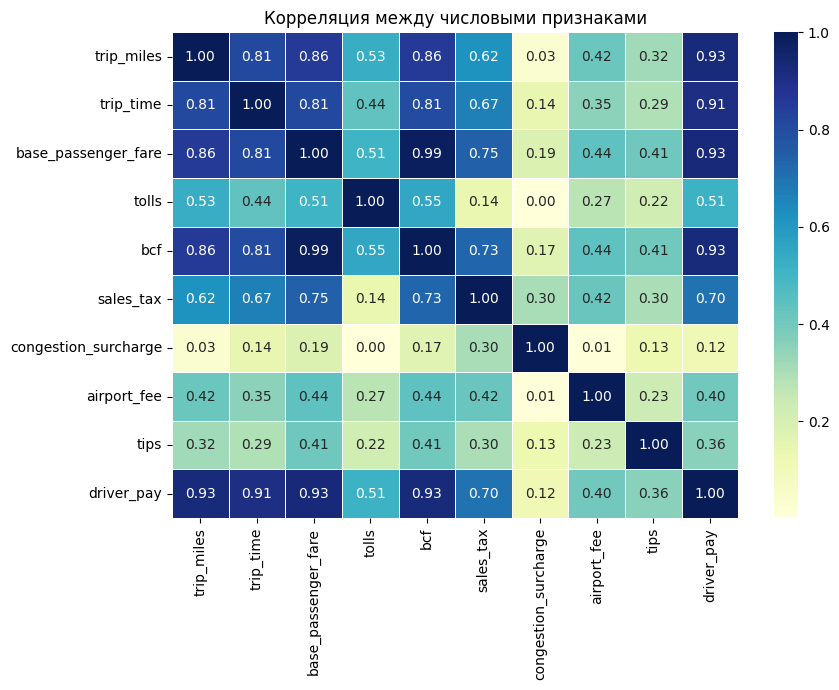

In [36]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9, 7))

ax.set_title("Корреляция между числовыми признаками")

sns.heatmap(
    data=corr_matrix_num,   # данные
    ax=ax,                  # график на котором будет отрисовка
    annot=True,             # подпись значений
    fmt=".2f",              # Сколько оставить после точки
    cmap='YlGnBu',          # Палитка
    linewidth=.5            # Отступ между квадратиками
)

plt.tight_layout() 
plt.show()

### Кросс-таблицы между категориальными признаками

In [27]:
crosstab = pd.crosstab(pd_df['shared_request_flag'], pd_df['shared_match_flag'])

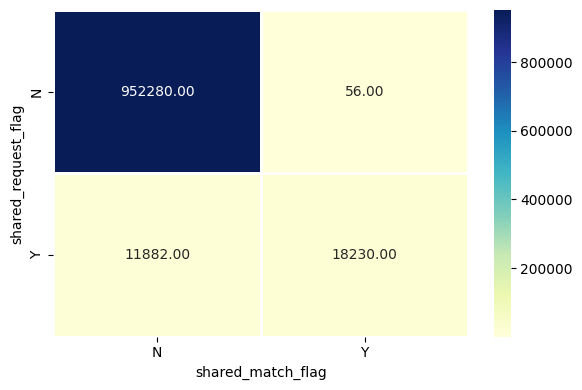

In [40]:
# Построение кросс-таблиц между категориальными признаками
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.heatmap(data=crosstab, ax=ax, annot=True, fmt=".2f", cmap='YlGnBu', linewidth=.9)

plt.tight_layout() 
plt.show()

### Выбросы

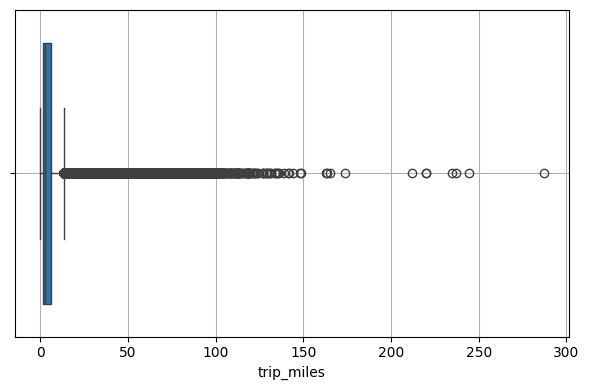

In [53]:
# Построение кросс-таблиц между категориальными признаками
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.boxplot(
    data=pd_df, 
    x="trip_miles", 
    ax=ax
)

plt.grid(True)
plt.tight_layout() 
plt.show()

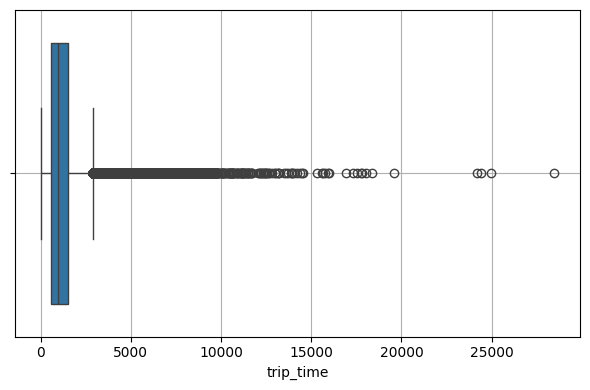

In [54]:
# Построение кросс-таблиц между категориальными признаками
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.boxplot(
    data=pd_df, 
    x="trip_time", 
    ax=ax
)

plt.grid(True)
plt.tight_layout() 
plt.show()

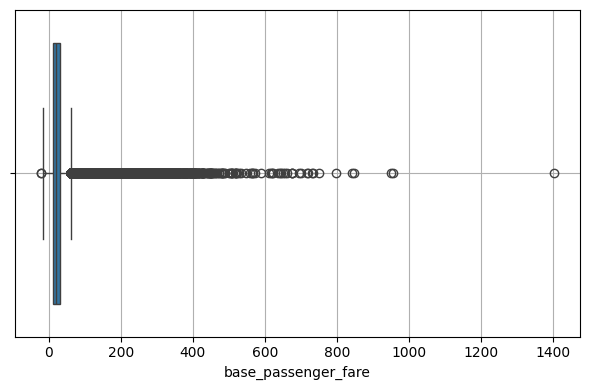

In [55]:
# Построение кросс-таблиц между категориальными признаками
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.boxplot(
    data=pd_df, 
    x="base_passenger_fare", 
    ax=ax
)

plt.grid(True)
plt.tight_layout() 
plt.show()

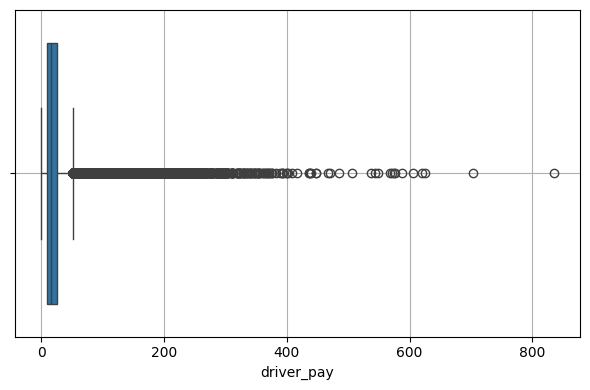

In [56]:
# Построение кросс-таблиц между категориальными признаками
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.boxplot(
    data=pd_df, 
    x="driver_pay", 
    ax=ax
)

plt.grid(True)
plt.tight_layout() 
plt.show()

### Диаграммы распределений

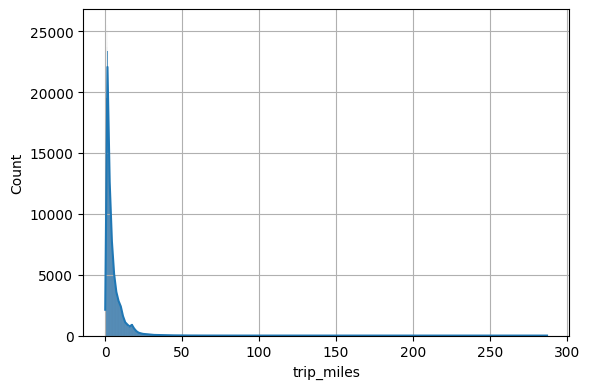

In [57]:
# Построение кросс-таблиц между категориальными признаками
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.histplot(
    data=pd_df, 
    x="trip_miles", 
    kde=True, 
    ax=ax, 
    alpha=0.7
)

plt.grid(True)
plt.tight_layout() 
plt.show()

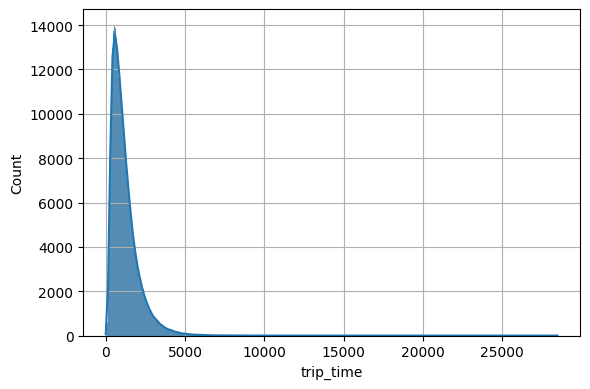

In [58]:
# Построение кросс-таблиц между категориальными признаками
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.histplot(
    data=pd_df, 
    x="trip_time", 
    kde=True, 
    ax=ax, 
    alpha=0.7
)

plt.grid(True)
plt.tight_layout() 
plt.show()

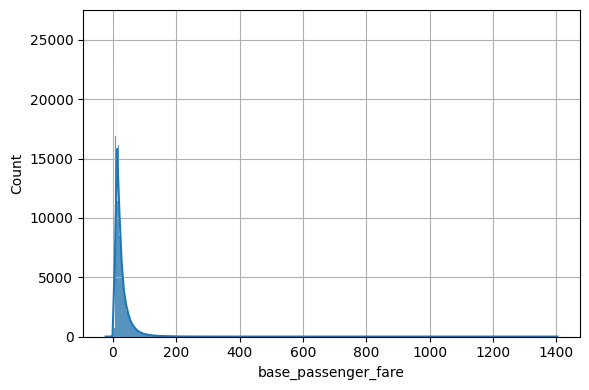

In [59]:
# Построение кросс-таблиц между категориальными признаками
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.histplot(
    data=pd_df, 
    x="base_passenger_fare", 
    kde=True, 
    ax=ax, 
    alpha=0.7
)

plt.grid(True)
plt.tight_layout() 
plt.show()

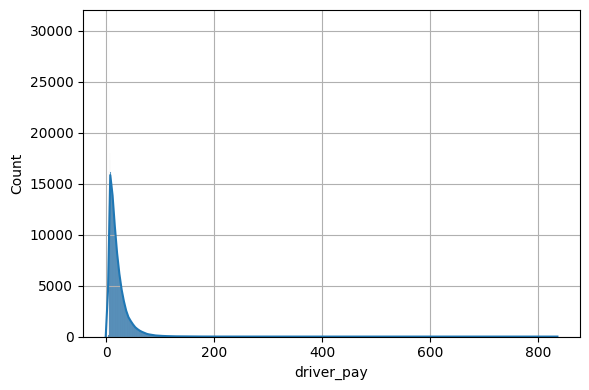

In [60]:
# Построение кросс-таблиц между категориальными признаками
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.histplot(
    data=pd_df, 
    x="driver_pay", 
    kde=True, 
    ax=ax, 
    alpha=0.7
)

plt.grid(True)
plt.tight_layout() 
plt.show()

## feature engineering

### Временные признаки

In [3]:
# === вытаскиваем данные из даты и времени запроса ===

pd_df['week_day_req'] = pd_df['request_datetime'].dt.weekday

pd_df['day_req'] = pd_df['request_datetime'].dt.day
pd_df['month_req'] = pd_df['request_datetime'].dt.month
pd_df['year_req'] = pd_df['request_datetime'].dt.year

pd_df['hour_req'] = pd_df['request_datetime'].dt.hour

pd_df['dayofweek_req'] = pd_df['request_datetime'].dt.dayofweek

In [4]:
# === время ожидания машины пассажиром ===
pd_df['time_wait_sec'] = (pd_df["on_scene_datetime"] - pd_df["request_datetime"]).dt.total_seconds().astype(int)

In [5]:
# === сколько пассажир ждал начала поездки ===
pd_df['time_wait_start_trip'] = (pd_df["pickup_datetime"] - pd_df["on_scene_datetime"]).dt.total_seconds().astype(int)

### Географические признаки

In [6]:
# поездка в рамкой одной зоны
pd_df['is_same_zone'] = pd_df['PULocationID'] == pd_df['DOLocationID']

### Бинарные признаки

In [7]:
# === Категории (Бинарные)
bin_cat_features = [
    "shared_request_flag",
    "shared_match_flag",
    "access_a_ride_flag",
    "wav_request_flag",
    "wav_match_flag"
]

for item in bin_cat_features:
    pd_df[item] = pd_df[item].apply(lambda x: 0 if x == 'N' else 1)

In [8]:
pd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 982448 entries, 0 to 982447
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   hvfhs_license_num     982448 non-null  object        
 1   dispatching_base_num  982448 non-null  object        
 2   originating_base_num  707791 non-null  object        
 3   request_datetime      982448 non-null  datetime64[ns]
 4   on_scene_datetime     982448 non-null  datetime64[ns]
 5   pickup_datetime       982448 non-null  datetime64[ns]
 6   dropoff_datetime      982448 non-null  datetime64[ns]
 7   PULocationID          982448 non-null  int32         
 8   DOLocationID          982448 non-null  int32         
 9   trip_miles            982448 non-null  float64       
 10  trip_time             982448 non-null  int64         
 11  base_passenger_fare   982448 non-null  float64       
 12  tolls                 982448 non-null  float64       
 13 

### Для классификациии таргет: shared_request_flag

In [10]:
# В таргете присутствует сильный дисбаланс классов
pd_df.groupby("shared_request_flag")['shared_request_flag'].count()

shared_request_flag
0    952336
1     30112
Name: shared_request_flag, dtype: int64

### Анализ временных признаков

Используем признаки, которые были получены ранее

In [ ]:
# request_datetime - 797940     - time - Когда поступил запрос
# on_scene_datetime - 803231    - time - Когда прибыл водитель
# pickup_datetime - 803755      - time - Когда началась поездка
# dropoff_datetime - 803177     - time - Когда закончилась поездка

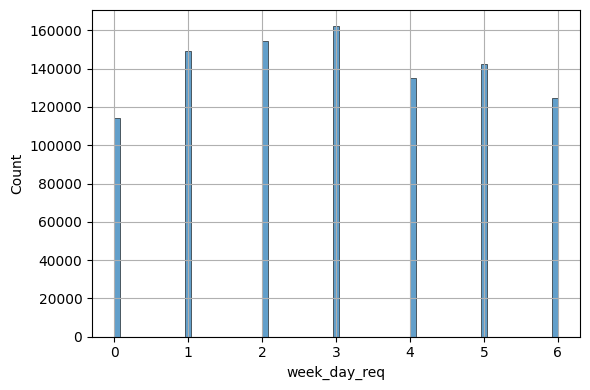

In [17]:
# Построение кросс-таблиц между категориальными признаками
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.histplot(
    data=pd_df, 
    x="week_day_req", 
    # kde=True, 
    ax=ax, 
    alpha=0.7
)

plt.grid(True)
plt.tight_layout() 
plt.show()

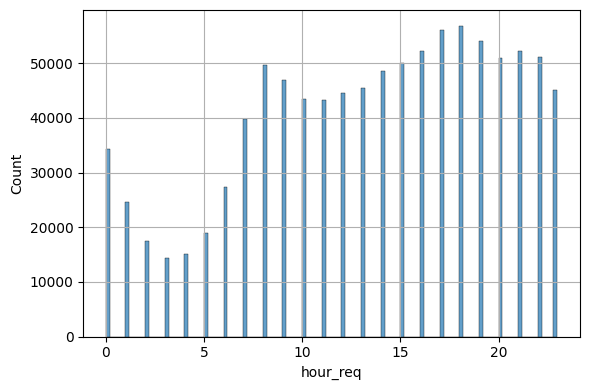

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.histplot(
    data=pd_df, 
    x="hour_req", 
    # kde=True, 
    ax=ax, 
    alpha=0.7
)

plt.grid(True)
plt.tight_layout() 
plt.show()

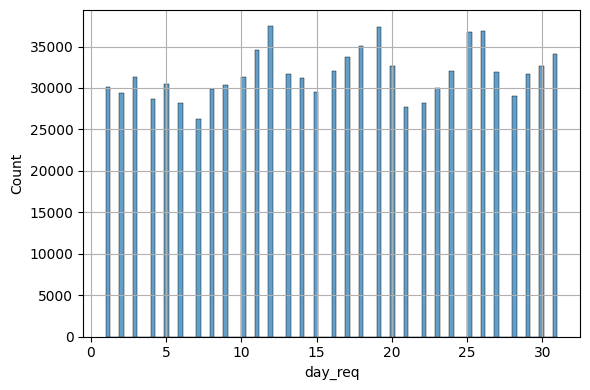

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

sns.histplot(
    data=pd_df, 
    x="day_req", 
    # kde=True, 
    ax=ax, 
    alpha=0.7
)

plt.grid(True)
plt.tight_layout() 
plt.show()

### Выбросы

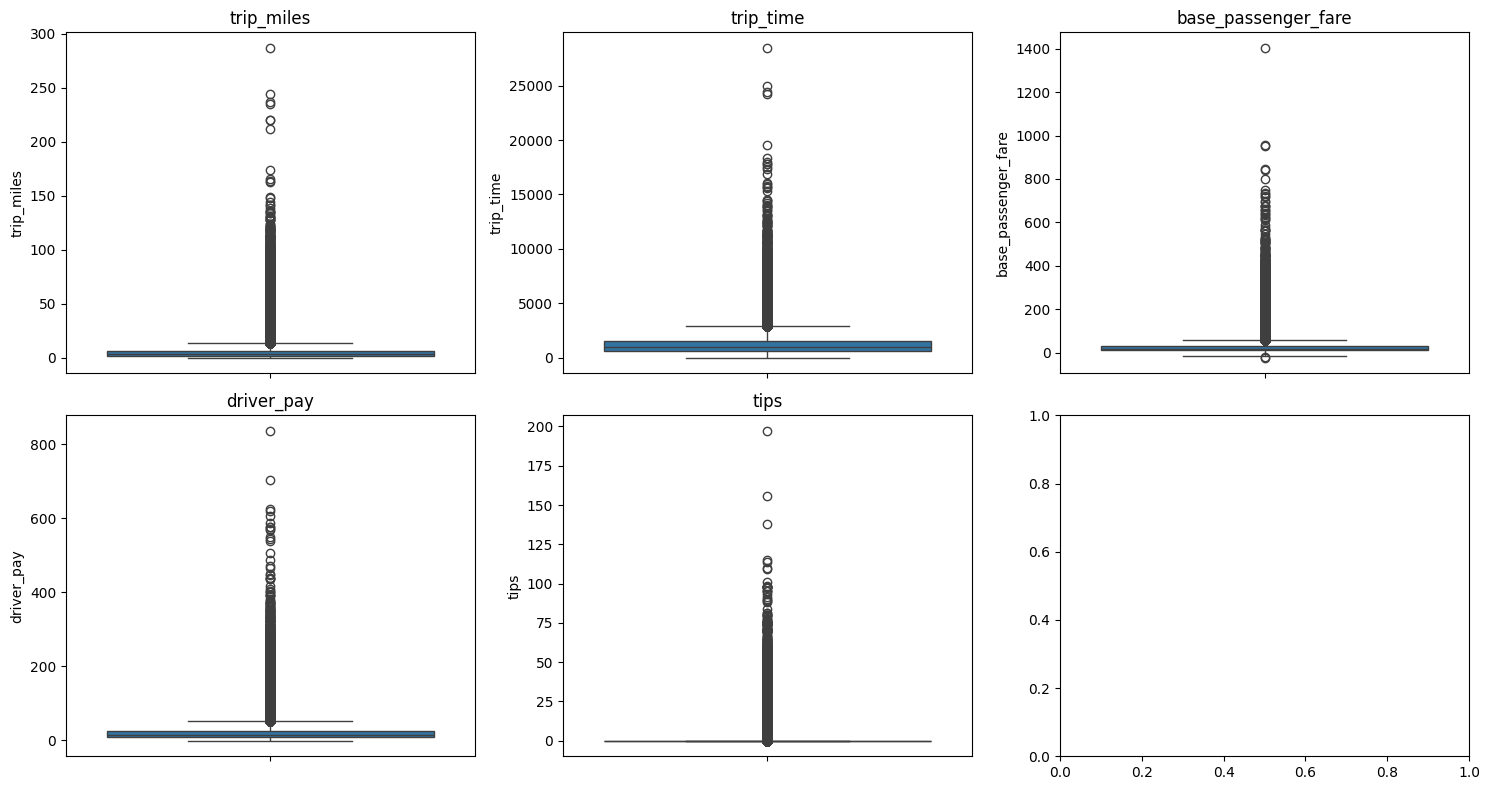

In [11]:
num_cols = ['trip_miles', 'trip_time', 'base_passenger_fare', 'driver_pay', 'tips']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
    sns.boxplot(data=pd_df, y=col, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

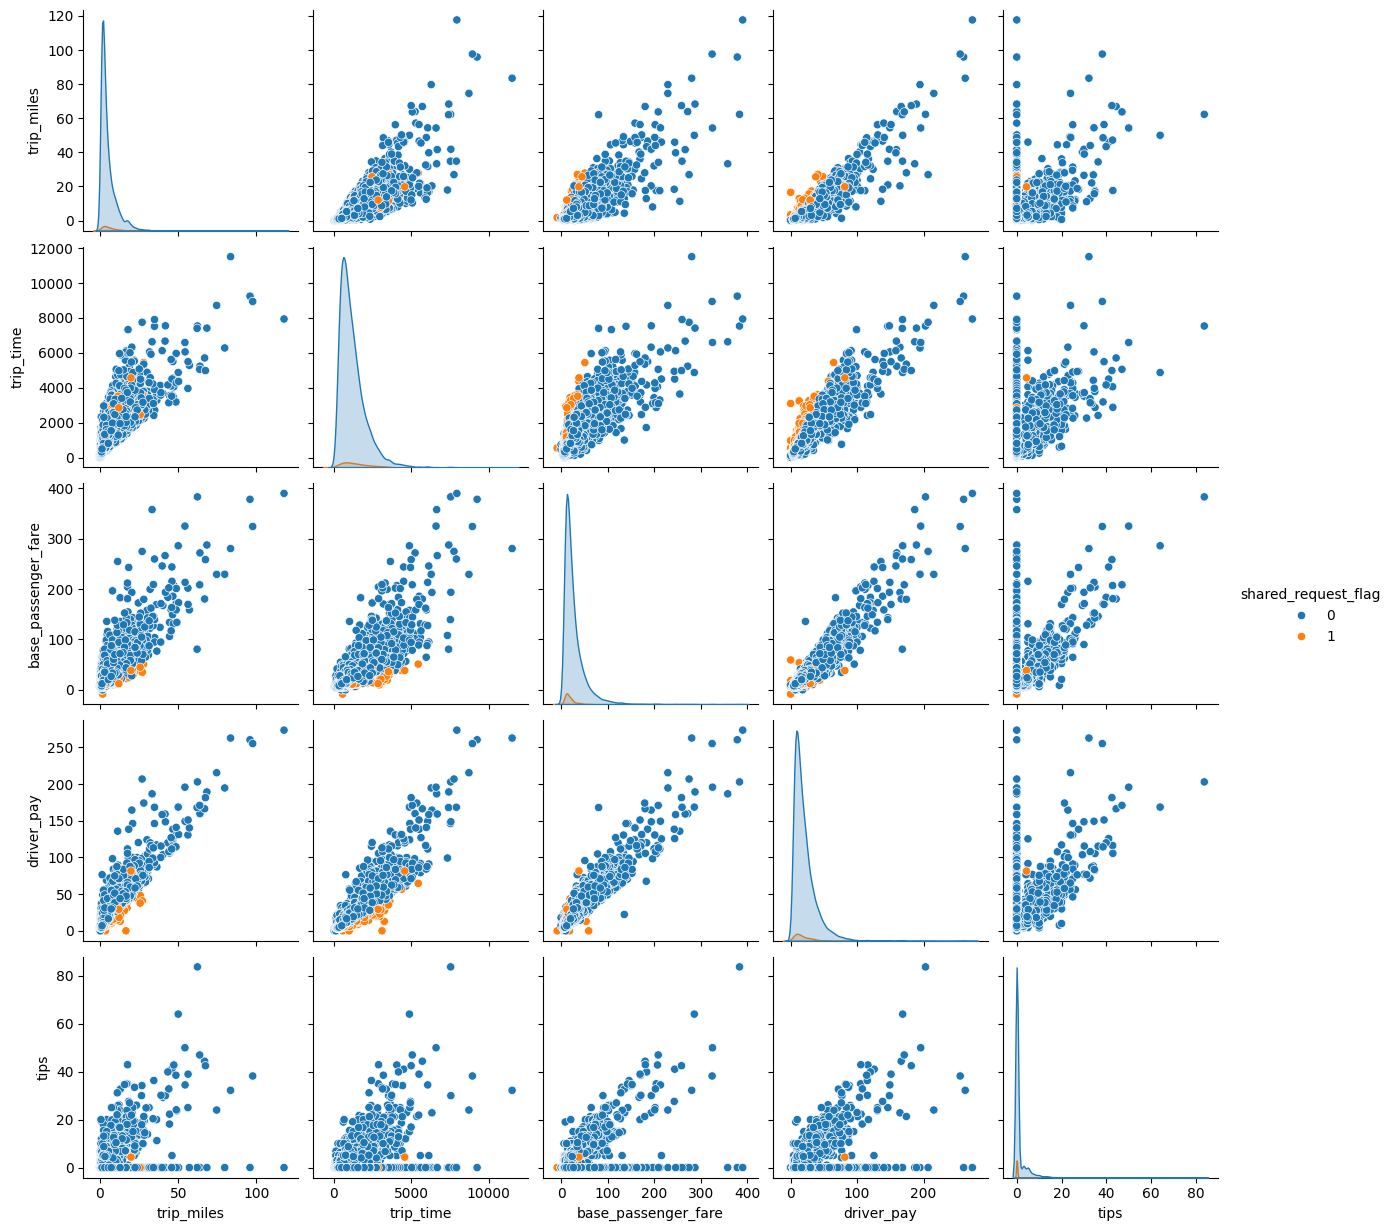

In [16]:
# 2. Pairplot (только на 10k строк, иначе упадёт)
sample_small = pd_df.sample(10000, random_state=42)
sns.pairplot(
    sample_small[['trip_miles', 'trip_time', 'base_passenger_fare', 'driver_pay', 'tips', 'shared_request_flag']], 
    diag_kind='kde',
    hue="shared_request_flag"
)
plt.show()

In [17]:
# 3. Таблицы сопряжённости + дисбаланс (для классификации shared_request_flag)
print(pd_df['shared_request_flag'].value_counts(normalize=True))
pd.crosstab(pd_df['shared_request_flag'], pd_df['wav_request_flag'])

shared_request_flag
0    0.96935
1    0.03065
Name: proportion, dtype: float64


wav_request_flag,0,1
shared_request_flag,,
0,949080,3256
1,30112,0


In [18]:
pd.crosstab(pd_df['hour_req'], pd_df['shared_request_flag'], normalize='index')

shared_request_flag,0,1
hour_req,,
0,0.951373,0.048627
1,0.952669,0.047331
2,0.950831,0.049169
3,0.950485,0.049515
4,0.952883,0.047117
5,0.955214,0.044786
6,0.957873,0.042127
7,0.962761,0.037239
8,0.971479,0.028521
